Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

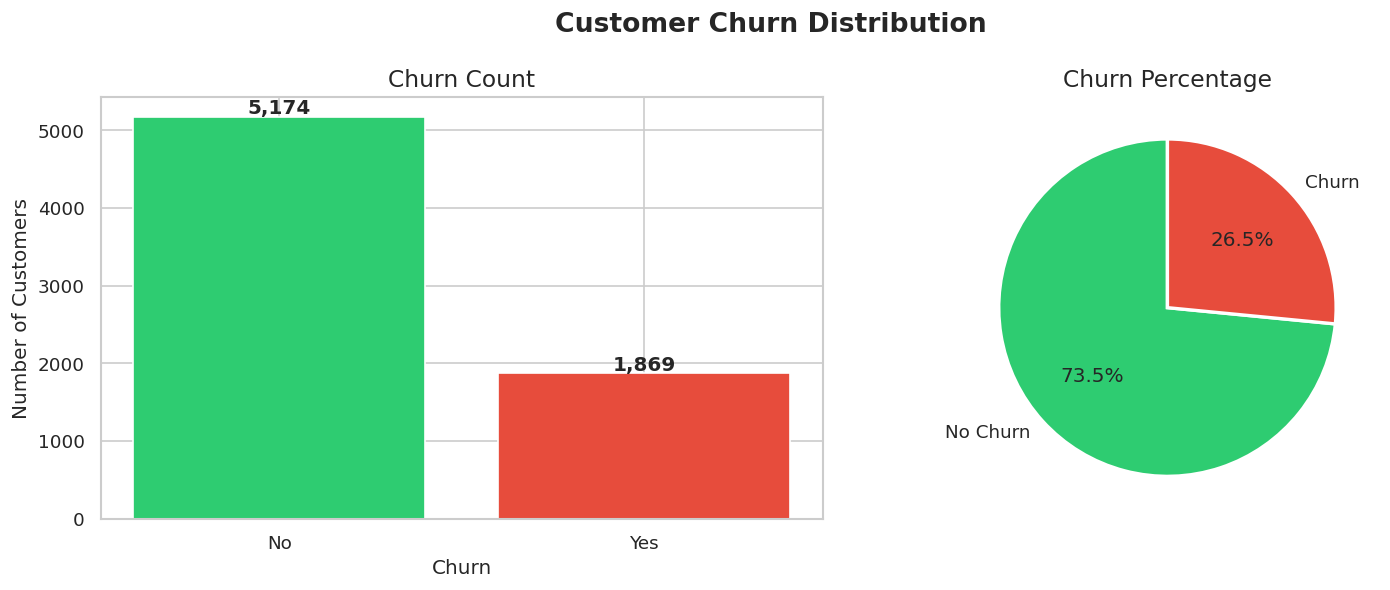

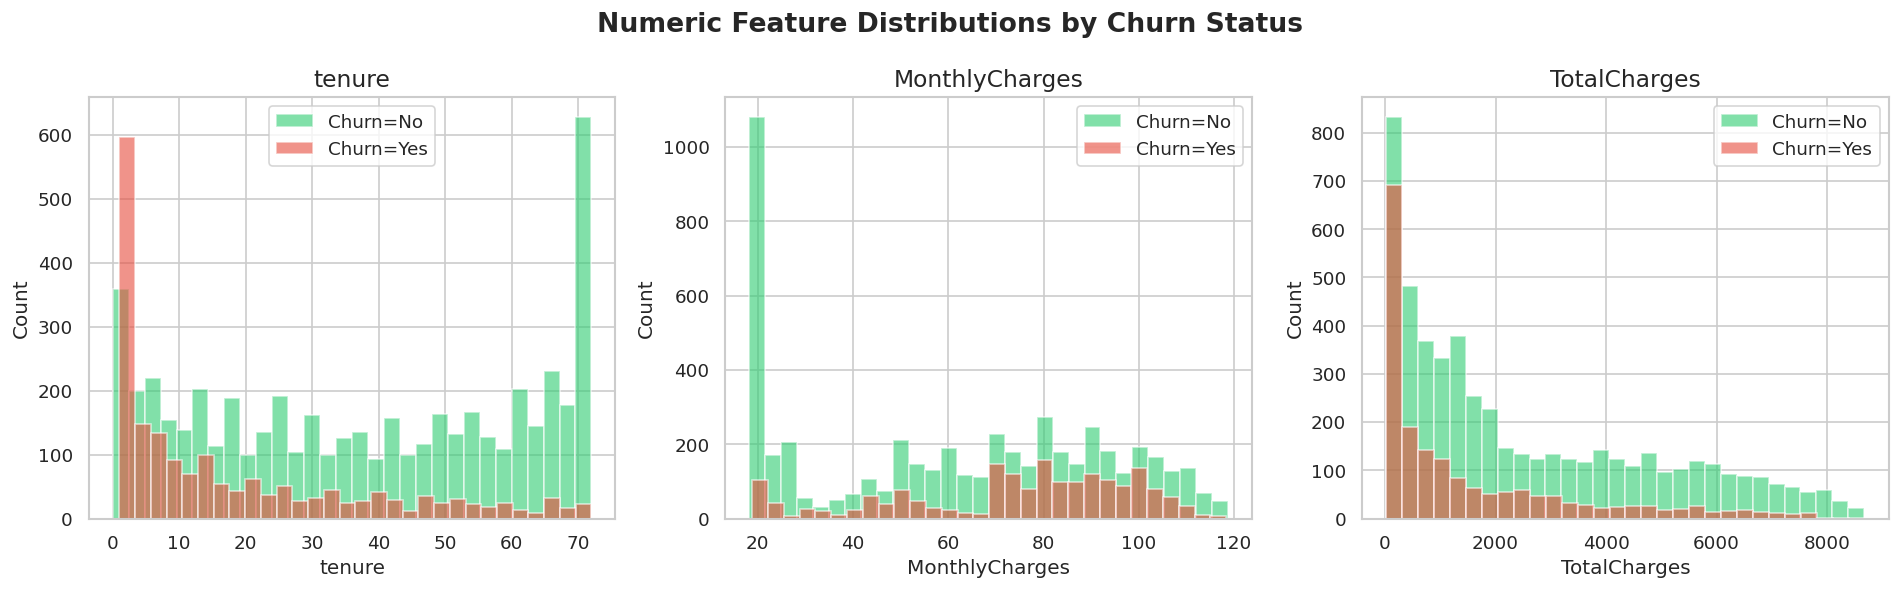

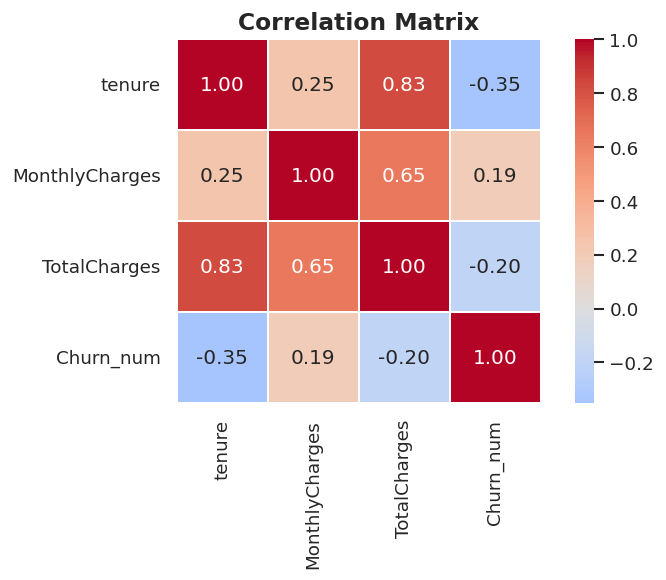

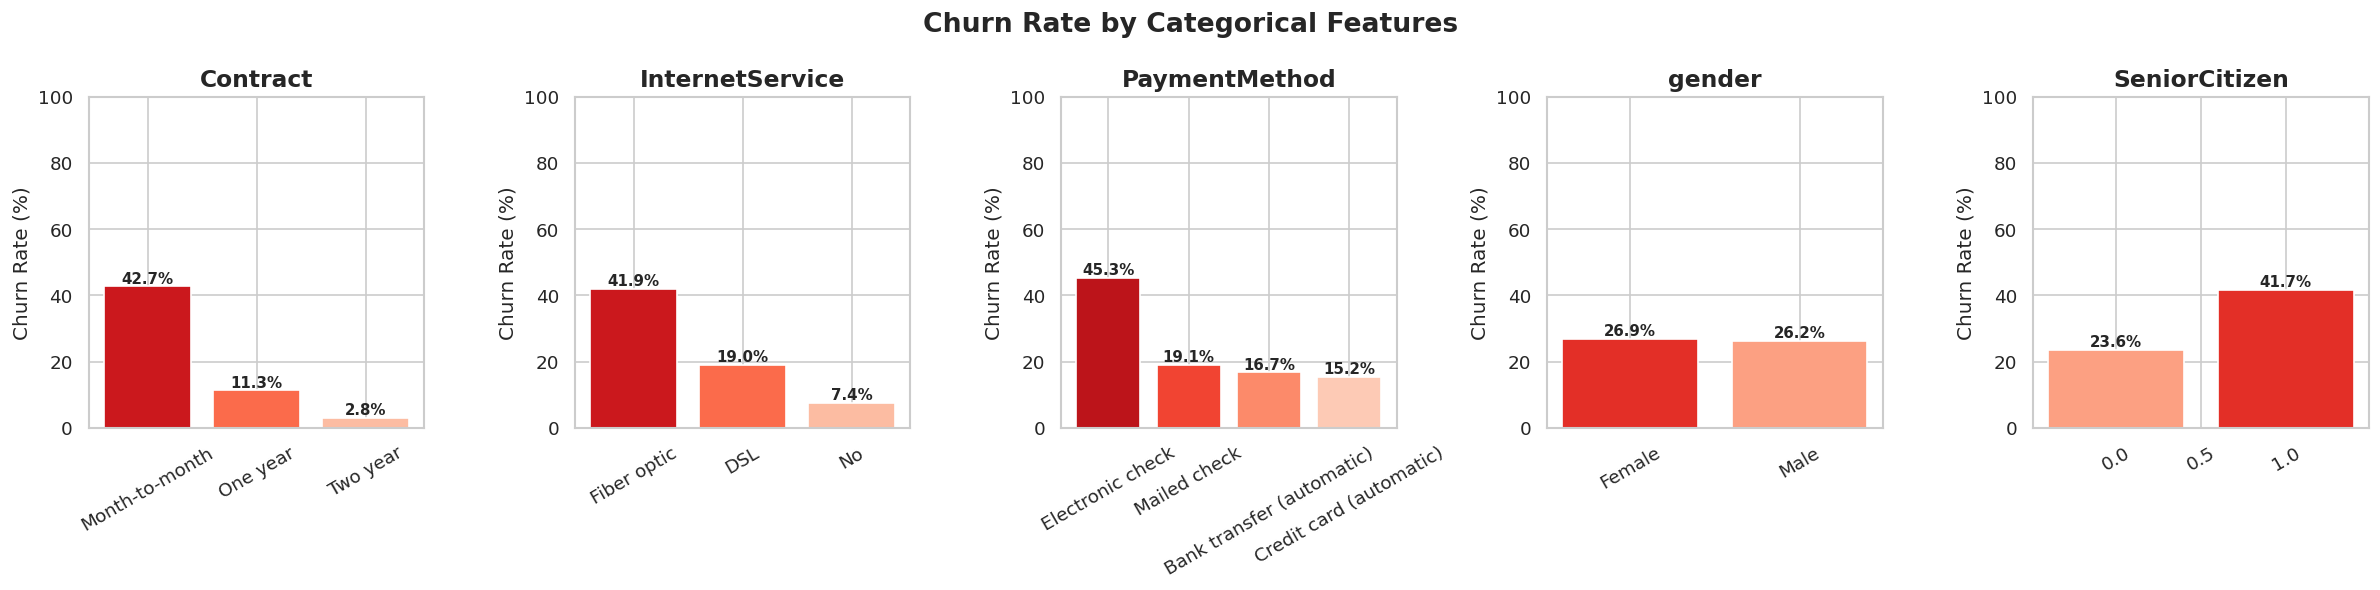

Training set: (5634, 19) | Test set: (1409, 19)
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Logistic Regression Accuracy: 0.8055
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



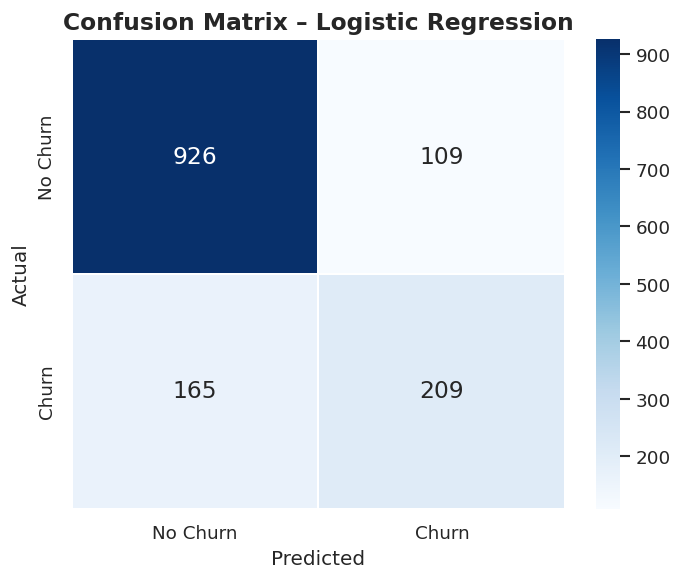

Random Forest Accuracy: 0.7779
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



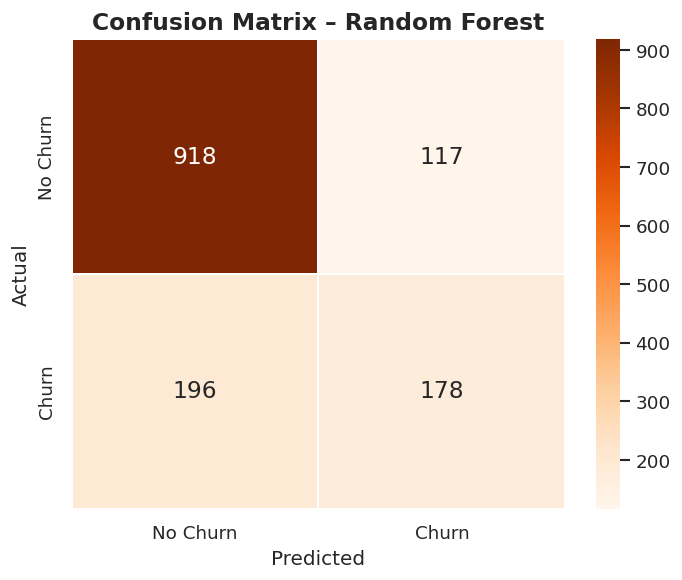

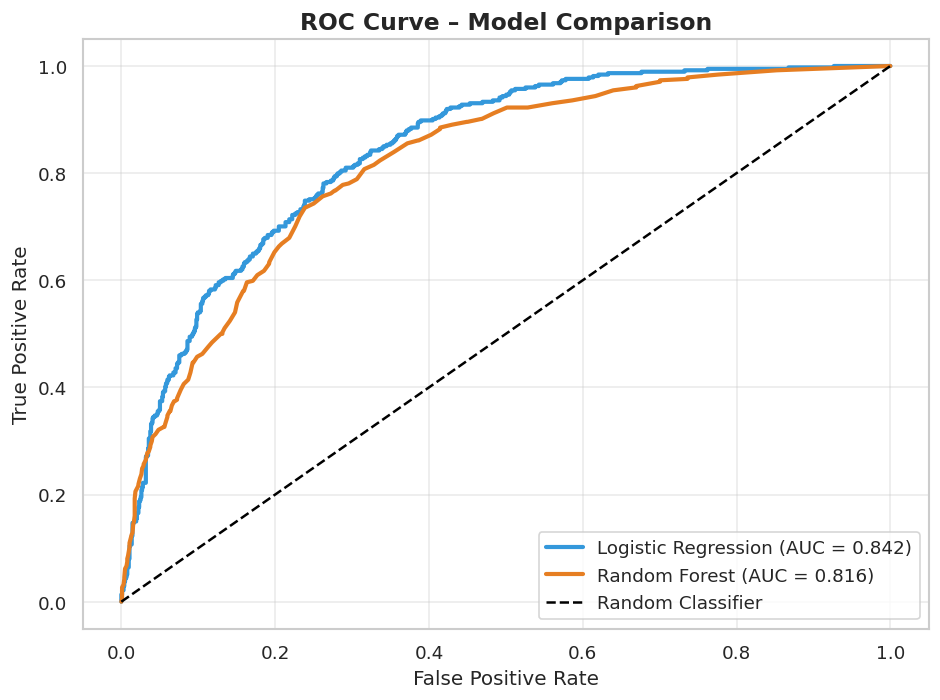

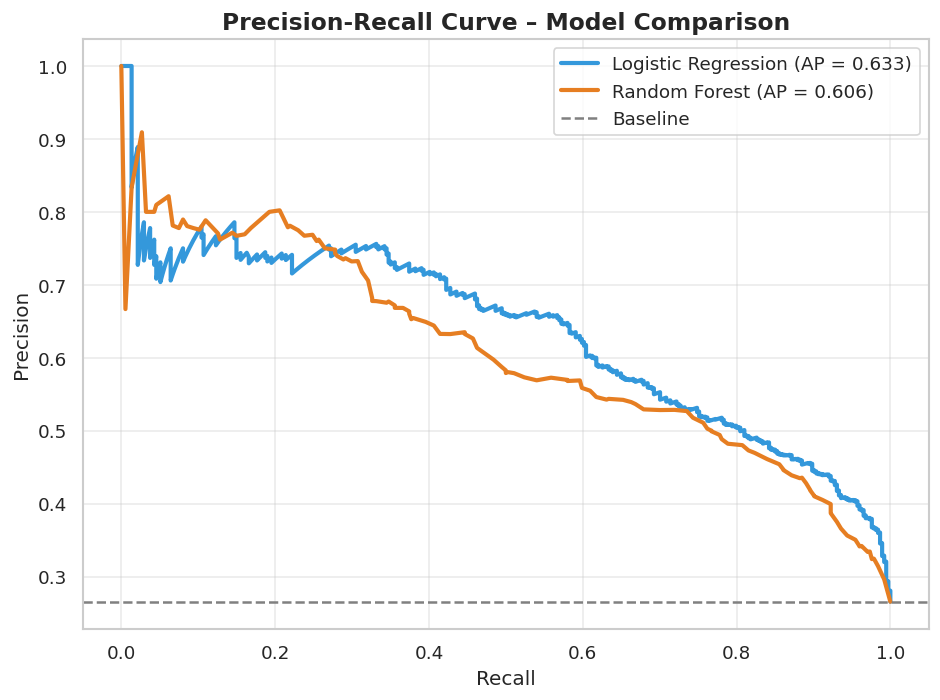

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV score: 0.7996
Test accuracy (best model): 0.8027


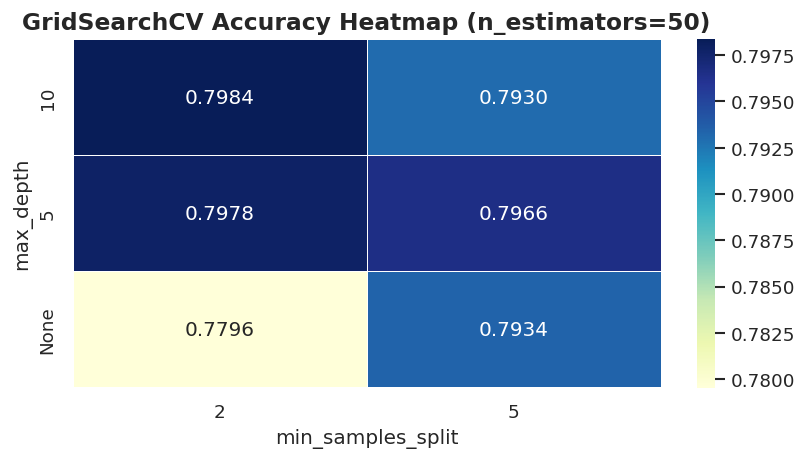

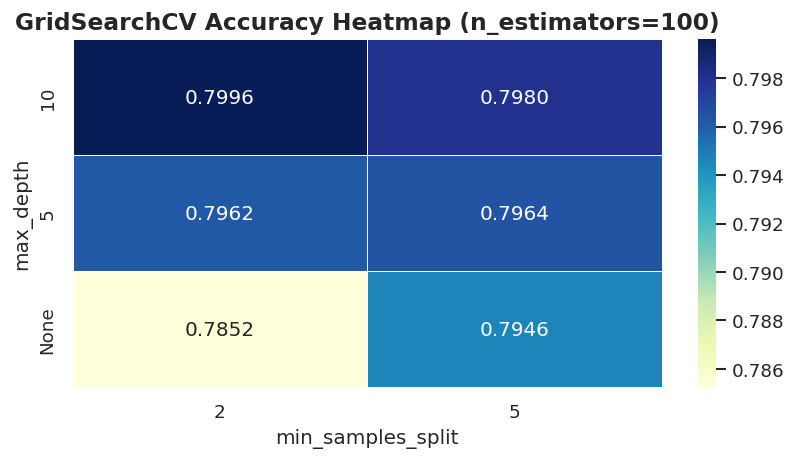

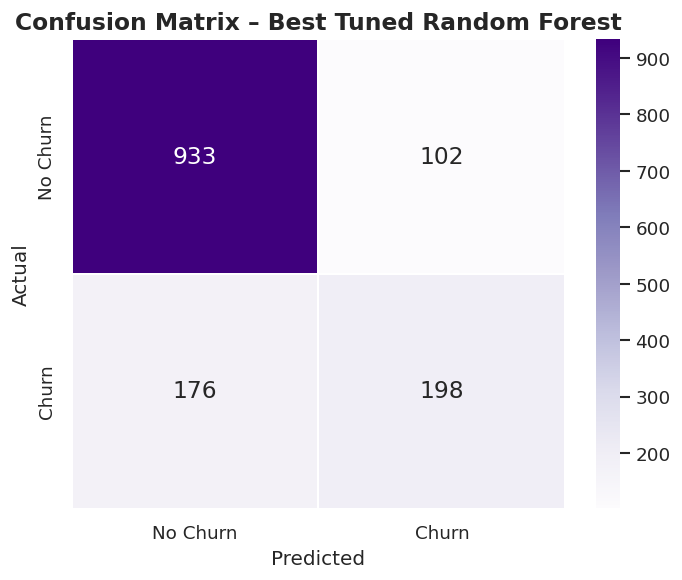

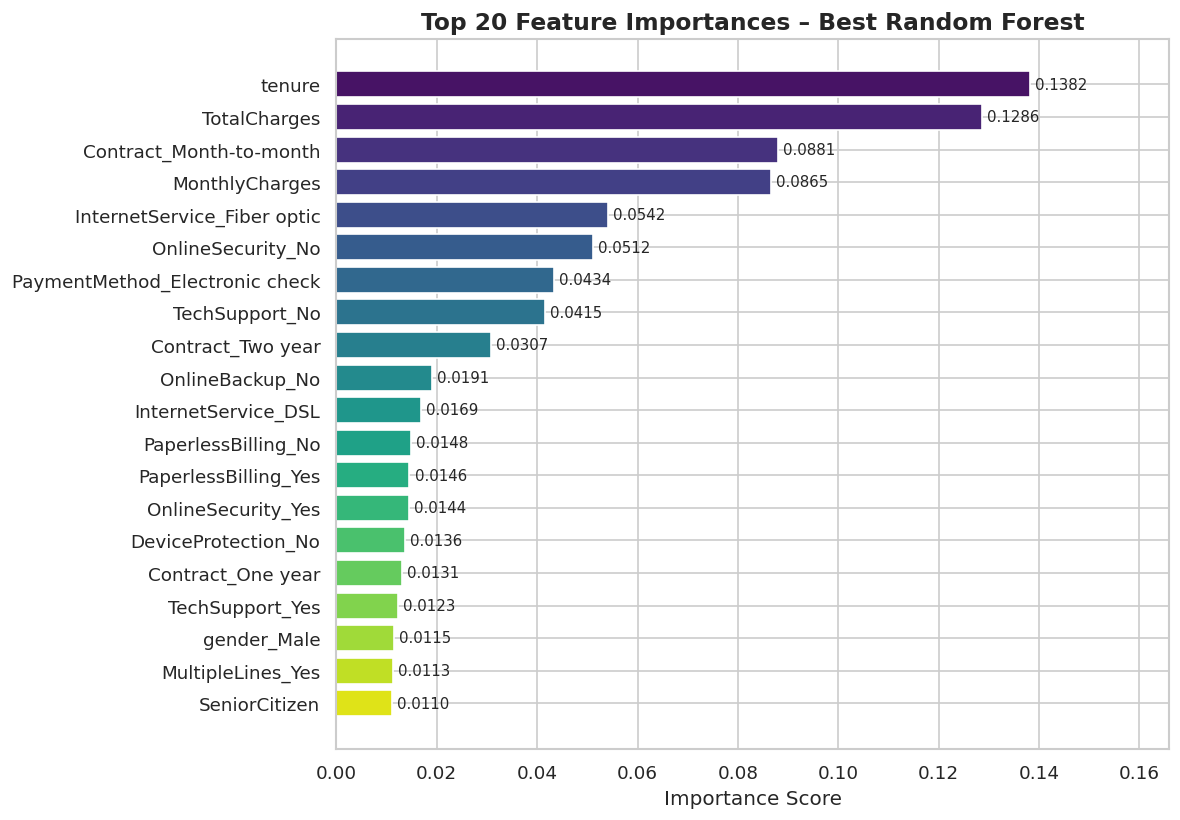

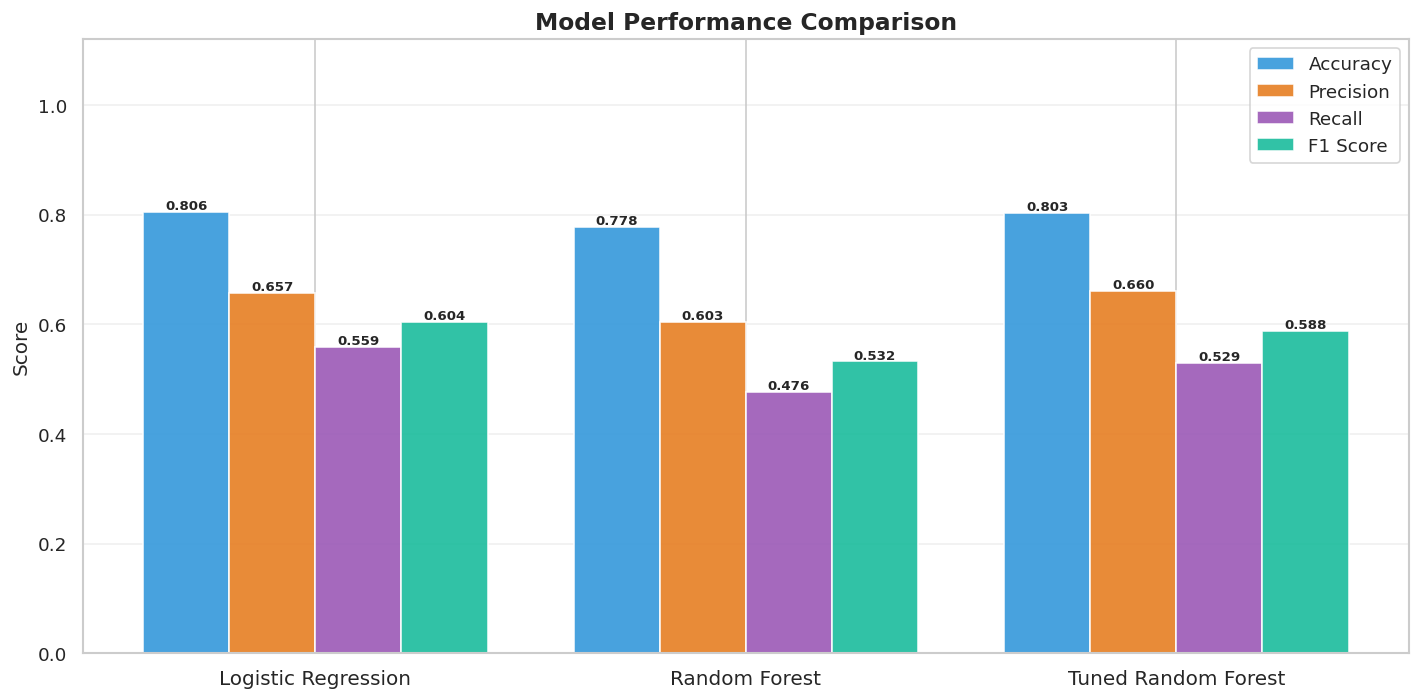


Model Comparison Table:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8055     0.6572  0.5588    0.6040
Random Forest          0.7779     0.6034  0.4759    0.5321
Tuned Random Forest    0.8027     0.6600  0.5294    0.5875


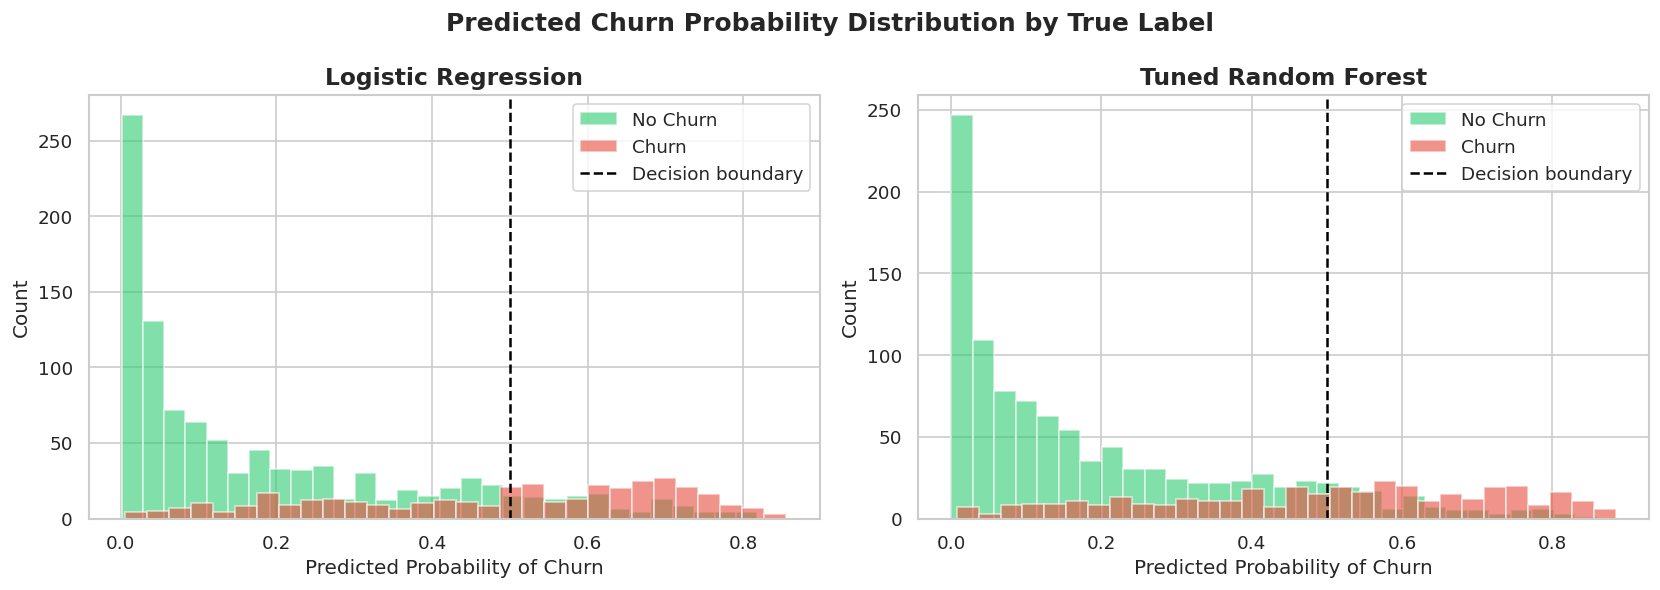

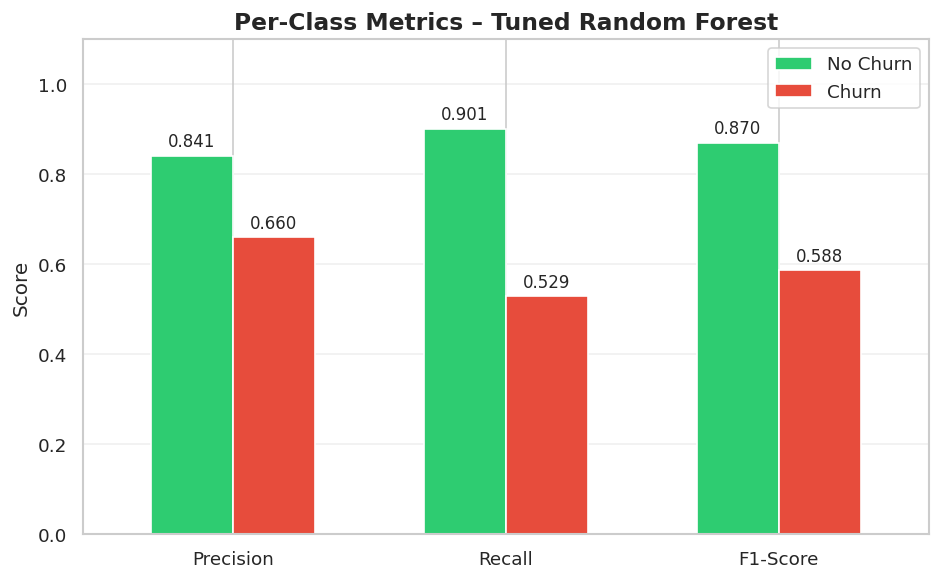

Pipeline saved as 'churn_prediction_pipeline.pkl'

Predicted churn: No
Probability – No Churn: 0.9841
Probability – Churn: 0.0159

TASK 2 COMPLETED SUCCESSFULLY!
✓ Built reusable ML pipeline with scikit-learn Pipeline API
✓ Handled numeric and categorical features automatically
✓ Trained Logistic Regression and Random Forest
✓ Hyperparameter tuning with GridSearchCV
✓ 14 visualizations: EDA, confusion matrices, ROC, PR curves,
  GridSearch heatmaps, feature importance, model comparison
✓ Exported complete pipeline using joblib
✓ Best Model Test Accuracy: 0.8027


In [1]:

#Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
#AI Internship - Developers Hub
#Submitted by : Muhammad Zoraiz Khan

!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             f1_score, precision_score, recall_score)
import joblib

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14, "axes.labelsize": 12})
COLORS = {"churn": "#E74C3C", "no_churn": "#2ECC71", "logreg": "#3498DB", "rf": "#E67E22", "best": "#9B59B6"}

df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.isnull().sum())

df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median(), inplace=True)
df_eda['Churn_num'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})

churn_counts = df['Churn'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Customer Churn Distribution", fontsize=16, fontweight='bold')
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS["no_churn"], COLORS["churn"]], edgecolor='white')
axes[0].set_title("Churn Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            colors=[COLORS["no_churn"], COLORS["churn"]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Churn Percentage")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Numeric Feature Distributions by Churn Status", fontsize=16, fontweight='bold')
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for label, color in [('No', COLORS["no_churn"]), ('Yes', COLORS["churn"])]:
        ax.hist(df_eda[df_eda['Churn'] == label][col], bins=30,
                alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.show()

corr_df = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

cat_features_eda = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen']
fig, axes = plt.subplots(1, len(cat_features_eda), figsize=(20, 5))
fig.suptitle("Churn Rate by Categorical Features", fontsize=16, fontweight='bold')
for ax, col in zip(axes, cat_features_eda):
    churn_rate = df_eda.groupby(col)['Churn_num'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=sns.color_palette("Reds_r", len(churn_rate)), edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

df_model = df.copy()
df_model.drop('customerID', axis=1, inplace=True)
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'].fillna(df_model['TotalCharges'].median(), inplace=True)
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Training set: {X_train.shape} | Test set: {X_test.shape}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)
y_prob_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(classification_report(y_test, y_pred_logreg))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
            linewidths=1, ax=ax, annot_kws={"size": 14})
ax.set_title("Confusion Matrix – Logistic Regression", fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
            linewidths=1, ax=ax, annot_kws={"size": 14})
ax.set_title("Confusion Matrix – Random Forest", fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for label, y_prob, color in [("Logistic Regression", y_prob_logreg, COLORS["logreg"]),
                               ("Random Forest", y_prob_rf, COLORS["rf"])]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{label} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – Model Comparison", fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for label, y_prob, color in [("Logistic Regression", y_prob_logreg, COLORS["logreg"]),
                               ("Random Forest", y_prob_rf, COLORS["rf"])]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, color=color, lw=2.5, label=f"{label} (AP = {ap:.3f})")
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1.5, label="Baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve – Model Comparison", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
print(f"Test accuracy (best model): {accuracy_score(y_test, y_pred_best):.4f}")

results_df = pd.DataFrame(grid_search.cv_results_)
for n_est in [50, 100]:
    subset = results_df[results_df['param_classifier__n_estimators'] == n_est].copy()
    subset['max_depth_label'] = subset['param_classifier__max_depth'].apply(
        lambda x: 'None' if x is None else str(x))
    pivot = subset.pivot_table(index='max_depth_label',
                               columns='param_classifier__min_samples_split',
                               values='mean_test_score')
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu",
                linewidths=0.5, ax=ax, annot_kws={"size": 12})
    ax.set_title(f"GridSearchCV Accuracy Heatmap (n_estimators={n_est})", fontweight='bold')
    ax.set_xlabel("min_samples_split")
    ax.set_ylabel("max_depth")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
            linewidths=1, ax=ax, annot_kws={"size": 14})
ax.set_title("Confusion Matrix – Best Tuned Random Forest", fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

ohe_features = list(best_model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .named_steps['onehot']
                    .get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_features
importances = best_model.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})\
    .sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=sns.color_palette("viridis", 20)[::-1], edgecolor='white')
ax.set_xlabel("Importance Score")
ax.set_title("Top 20 Feature Importances – Best Random Forest", fontweight='bold')
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlim(0, feat_imp_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.show()

def get_metrics(y_true, y_pred):
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1 Score': f1_score(y_true, y_pred)}

metrics = {'Logistic Regression': get_metrics(y_test, y_pred_logreg),
           'Random Forest': get_metrics(y_test, y_pred_rf),
           'Tuned Random Forest': get_metrics(y_test, y_pred_best)}
metrics_df = pd.DataFrame(metrics).T

x = np.arange(len(metrics_df.index))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics_df.columns,
                                         [COLORS["logreg"], COLORS["rf"], COLORS["best"], "#1ABC9C"])):
    bars = ax.bar(x + i * width, metrics_df[metric], width,
                  label=metric, color=color, edgecolor='white', alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nModel Comparison Table:")
print(metrics_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicted Churn Probability Distribution by True Label", fontsize=15, fontweight='bold')
for ax, (label, y_prob, color) in zip(axes, [("Logistic Regression", y_prob_logreg, COLORS["logreg"]),
                                               ("Tuned Random Forest", y_prob_best, COLORS["best"])]):
    for churn_val, c, lbl in [(0, COLORS["no_churn"], "No Churn"), (1, COLORS["churn"], "Churn")]:
        ax.hist(y_prob[y_test == churn_val], bins=30, alpha=0.6,
                color=c, label=lbl, edgecolor='white')
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision boundary')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Predicted Probability of Churn")
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_pred_best, output_dict=True)
class_df = pd.DataFrame({
    'No Churn': [report['0']['precision'], report['0']['recall'], report['0']['f1-score']],
    'Churn':    [report['1']['precision'], report['1']['recall'], report['1']['f1-score']],
}, index=['Precision', 'Recall', 'F1-Score'])

fig, ax = plt.subplots(figsize=(8, 5))
class_df.plot(kind='bar', ax=ax, color=[COLORS["no_churn"], COLORS["churn"]],
              edgecolor='white', width=0.6)
ax.set_title("Per-Class Metrics – Tuned Random Forest", fontweight='bold')
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_xticklabels(class_df.index, rotation=0)
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(best_model, 'churn_prediction_pipeline.pkl')
print("Pipeline saved as 'churn_prediction_pipeline.pkl'")

loaded_pipeline = joblib.load('churn_prediction_pipeline.pkl')
sample = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(sample)
probability = loaded_pipeline.predict_proba(sample)

print(f"\nPredicted churn: {'Yes' if prediction[0] == 1 else 'No'}")
print(f"Probability – No Churn: {probability[0][0]:.4f}")
print(f"Probability – Churn: {probability[0][1]:.4f}")

print("\n" + "="*50)
print("TASK 2 COMPLETED SUCCESSFULLY!")
print("="*50)
print("✓ Built reusable ML pipeline with scikit-learn Pipeline API")
print("✓ Handled numeric and categorical features automatically")
print("✓ Trained Logistic Regression and Random Forest")
print("✓ Hyperparameter tuning with GridSearchCV")
print("✓ 14 visualizations: EDA, confusion matrices, ROC, PR curves,")
print("  GridSearch heatmaps, feature importance, model comparison")
print("✓ Exported complete pipeline using joblib")
print(f"✓ Best Model Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")